In [1]:
from elos.elo_tracker import EloTracker
from utils.utils import load_all_games_csv, get_teams, plot_elo_ratings_over_time, plot_elos_distribution, get_prev_date_midnight, TEAM_FULLNAME_MAP
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt
import json

# All Season Elos

This notebook will collect the Elo ratings over time for all teams given in `gameinfo_cleaned.csv`. Here the ratings are simply calculated
via final results (win or loss), meaning play-by-play data is unnecessary.

It will then look into the distribution and create a Gaussian approximation.

It will then save the ratings to a `.json` file for visualization on a webpage.

## Get all Games

In [2]:
all_games = load_all_games_csv('../data/gameinfo_cleaned.csv')

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/utils.py:27: DtypeWarning: Columns (10,11,13,17,19,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  all_games = pd.read_csv(filename)


## Elo Ratings Updates for All Years

In [3]:
teams = get_teams(all_games)
et = EloTracker(teams)

et.add_history(all_games)

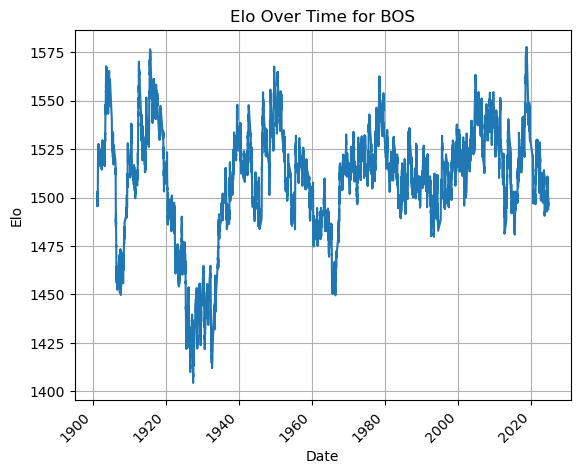

In [4]:
# Example: Red Sox
plot_elo_ratings_over_time('BOS', et.elos_map)

## Elo Ratings Distributions

### For all Teams over All Years

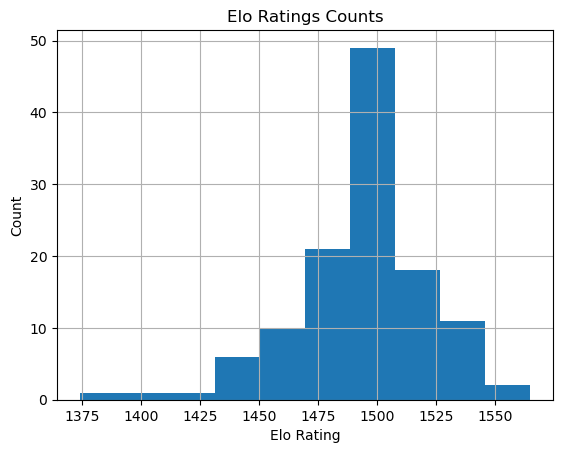

Mean: 1493.3194868182259
Std: 28.5622929081485


In [5]:
# Plot distribution of elos for all teams
mean, std = plot_elos_distribution(teams, et.elos_map)
print("Mean:", mean)
print("Std:",std)


### For 2024 Teams over All Years

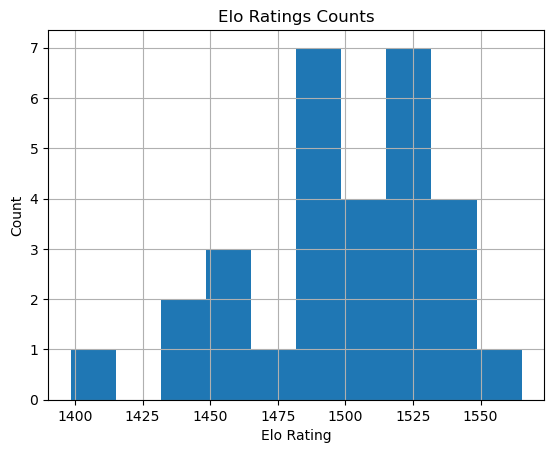

Mean: 1500.004065688554
Std: 34.45117071579272


In [6]:
# Plot distribution of elos for all teams
games_24 = all_games[all_games['season']==2024]
teams_24 = get_teams(games_24)


mean, std = plot_elos_distribution(teams_24, et.elos_map)
print("Mean:", mean)
print("Std:",std)

### Gaussian Approximation

Text(0.5, 1.0, 'Elo Rating Normal PDF')

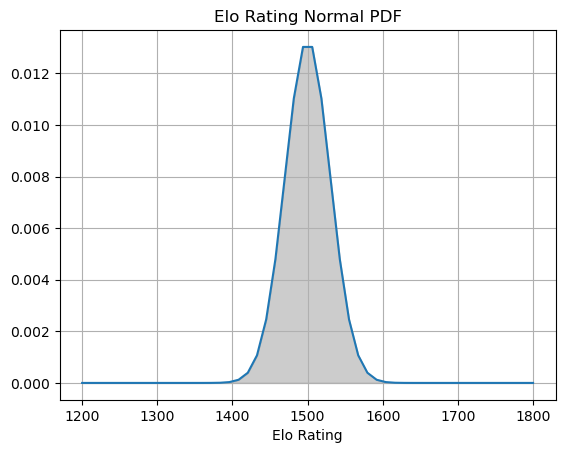

In [11]:
xp = np.linspace(1200,1800)
yp = norm.pdf(xp, loc=1500, scale=30)
plt.grid()
plt.plot(xp,yp)
plt.fill_between(xp, yp, color='gray', alpha=0.4)
plt.xlabel("Elo Rating")
plt.title("Elo Rating Normal PDF")

## Save Ratings to `.json`

In [8]:
elo_json = {}
for team, history in et.elos_map.items():
    fullname = TEAM_FULLNAME_MAP[team]
    elo_json[fullname] = []
    for _, date, initial_elo, updated_elo, _, wins, losses, season, first_game in history:
        if first_game: # If it's the first game of the season, we need an additional entry for before it starts
            prev_dt = get_prev_date_midnight(date)
            elo_json[fullname].append({
                'date': prev_dt.isoformat(),
                'elo': initial_elo,
                'wins': 0,
                'losses': 0,
            })
            
        elo_json[fullname].append({
            'date': date.isoformat(),
            'elo': updated_elo,
            'wins': wins,
            'losses': losses,
        })
        

In [9]:
elo_json['Boston Red Sox (1901 - 2024)']

[{'date': '1901-04-25T00:00:00', 'elo': 1500, 'wins': 0, 'losses': 0},
 {'date': '1901-04-26T12:00:00', 'elo': 1498.5, 'wins': 0, 'losses': 1},
 {'date': '1901-04-27T12:00:00',
  'elo': 1497.0129517192652,
  'wins': 0,
  'losses': 2},
 {'date': '1901-04-29T12:00:00',
  'elo': 1495.5129517192652,
  'wins': 0,
  'losses': 3},
 {'date': '1901-04-30T12:00:00',
  'elo': 1497.0259034385303,
  'wins': 1,
  'losses': 3},
 {'date': '1901-05-01T12:00:00',
  'elo': 1495.5257916043965,
  'wins': 1,
  'losses': 4},
 {'date': '1901-05-02T12:00:00',
  'elo': 1497.0386324633764,
  'wins': 2,
  'losses': 4},
 {'date': '1901-05-03T12:00:00',
  'elo': 1495.5640896611687,
  'wins': 2,
  'losses': 5},
 {'date': '1901-05-04T12:00:00',
  'elo': 1497.1022732787617,
  'wins': 3,
  'losses': 5},
 {'date': '1901-05-06T12:00:00',
  'elo': 1498.6271811124682,
  'wins': 4,
  'losses': 5},
 {'date': '1901-05-07T12:00:00',
  'elo': 1500.1389238832915,
  'wins': 5,
  'losses': 5},
 {'date': '1901-05-08T12:00:00',
  'e

In [10]:
with open("../../web/elo-exploration/public/elos.json", "w") as f:
    json.dump(elo_json, f, indent=2)